# Results Visualisation — PINN vs NLS Benchmark

Reads `sensitivity_1comp.csv` and `sensitivity_2comp.csv` and produces:
- publication-ready figures (PNG)
- summary table with median [IQR] errors
- LaTeX version of the table for direct inclusion in the paper

**Run only after the sensitivity analysis has finished.**

## 0. Setup

In [18]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

TAB_DIR = Path("../results/tables")
FIG_DIR = Path("../results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family":     "serif",
    "font.size":        11,
    "axes.titlesize":   11,
    "axes.labelsize":   11,
    "legend.fontsize":   9,
    "figure.dpi":       130,
})
PINN_C  = "#2166ac"   # plava
BENCH_C = "#d6604d"   # crvena

N_VALUES     = [3, 5, 8, 10, 12]
SIGMA_VALUES = [0.0, 0.05, 0.10, 0.20]
SIGMA_LABELS = [r"$\sigma=0$", r"$\sigma=5\%$", r"$\sigma=10\%$", r"$\sigma=20\%$"]

print("Setup OK.")

Setup OK.


## 1. Data Loading and Cleaning

In [19]:
def load(model):
    path = TAB_DIR / f"sensitivity_{model}.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
    raw = pd.read_csv(path)
    ok  = raw[raw["status"] == "ok"].copy()
    n_fail = len(raw) - len(ok)
    print(f"{model}: {len(ok)}/{len(raw)} ok"
          + (f", {n_fail} failed" if n_fail else ""))
    return raw, ok

raw1, df1 = load("1comp")
raw2, df2 = load("2comp")

print()
print("=== 1-comp preview ===")
display(df1[["N","sigma","seed","pinn_err_k10","bench_err_k10","bench_success"]].head(8))

print("\n=== 2-comp preview ===")
display(df2[["N","sigma","seed","pinn_err_k10","bench_err_k10","bench_success"]].head(8))

1comp: 600/600 ok
2comp: 600/600 ok

=== 1-comp preview ===


,N,sigma,seed,pinn_err_k10,bench_err_k10,bench_success
0,3,0.0,0,0.362093,7.886754e-14,True
1,3,0.0,1,0.026144,1.273284e-13,True
2,3,0.0,2,0.114903,2.250649e-13,True
3,3,0.0,3,0.029970,0.000000e+00,True
4,3,0.0,4,0.000032,1.585564e-14,True
5,3,0.0,5,0.132539,1.005846e-13,True
6,3,0.0,6,0.021018,1.807386e-14,True
7,3,0.0,7,0.054533,1.114333e-13,True



=== 2-comp preview ===


,N,sigma,seed,pinn_err_k10,bench_err_k10,bench_success
0,3,0.0,0,19.557570,99.068594,True
1,3,0.0,1,22.289560,96.209300,True
2,3,0.0,2,9.329726,96.301981,True
3,3,0.0,3,21.630720,95.390404,True
4,3,0.0,4,16.024899,91.463029,True
5,3,0.0,5,14.091112,32.383395,True
6,3,0.0,6,3.909348,47.694606,True
7,3,0.0,7,7.984372,65.548091,True


In [20]:
# Overall error statistics
print("=== 1-comp: err_k10 (all N and sigma) ===")
print(df1[["pinn_err_k10","bench_err_k10"]].describe().round(2))

print("\n=== 2-comp: err_k10 ===")
print(df2[["pinn_err_k10","bench_err_k10"]].describe().round(2))

print("\n=== 2-comp: NLS convergence rate ===")
success = raw2.groupby(["N","sigma"])["bench_success"].mean().mul(100).unstack("sigma")
success.columns = [f"{s:.0%}" for s in success.columns]
display(success.round(0))

=== 1-comp: err_k10 (all N and sigma) ===
       pinn_err_k10  bench_err_k10
count        600.00         600.00
mean           8.88           8.85
std           13.16          13.12
min            0.00           0.00
25%            0.18           0.05
50%            4.06           4.08
75%           12.05          12.03
max           99.99          99.85

=== 2-comp: err_k10 ===
       pinn_err_k10  bench_err_k10
count        600.00         600.00
mean          21.15          53.29
std           25.92          75.00
min            0.09           0.00
25%            5.55           3.13
50%           13.53          27.90
75%           25.67          96.26
max          260.92         749.57

=== 2-comp: NLS convergence rate ===


,0%,5%,10%,20%
N,,,,
3,100.0,100.0,100.0,100.0
5,100.0,100.0,100.0,100.0
8,100.0,100.0,100.0,100.0
10,100.0,100.0,100.0,100.0
12,100.0,100.0,100.0,100.0


---
## 2. Helper Functions

In [21]:
def line_err_vs_N(df, pinn_col, bench_col, ax, sigma,
                  ylabel="Error (%)", title=""):
    """Median ± IQR shading for one sigma level."""
    sub = df[df["sigma"] == sigma]
    for col, c, lbl in [(pinn_col, PINN_C, "PINN"),
                         (bench_col, BENCH_C, "NLS")]:
        grp = sub.groupby("N")[col]
        med, q1, q3 = grp.median(), grp.quantile(0.25), grp.quantile(0.75)
        ax.plot(med.index, med.values, "o-", color=c, lw=2, label=lbl, zorder=3)
        ax.fill_between(med.index, q1.values, q3.values,
                         alpha=0.15, color=c, zorder=2)
    ax.set_xlabel("Number of measurements (N)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(N_VALUES)
    ax.grid(True, alpha=0.3)
    ax.legend()


def heatmap_median(df, col, ax, title, vmax=None, fmt=".1f"):
    """Heatmap of median(col) by sigma × N."""
    pivot = (df.groupby(["sigma","N"])[col]
               .median().unstack("N"))
    pivot.index = [f"{s:.0%}" for s in pivot.index]
    sns.heatmap(pivot, ax=ax, annot=True, fmt=fmt,
                cmap="YlOrRd", vmin=0, vmax=vmax,
                linewidths=0.5, linecolor="white",
                cbar_kws={"label": "Median (%)"})
    ax.set_xlabel("Number of measurements (N)")
    ax.set_ylabel("Noise level (σ)")
    ax.set_title(title)


def boxplot_by_N(df, pinn_col, bench_col, ax, sigma, ylabel, title):
    """Box plot of error distribution for one sigma level."""
    sub = df[df["sigma"] == sigma].copy()
    long = []
    for _, r in sub.iterrows():
        long.append({"N": r["N"], "Method": "PINN",  "err": r[pinn_col]})
        long.append({"N": r["N"], "Method": "NLS",   "err": r[bench_col]})
    long = pd.DataFrame(long).dropna()
    sns.boxplot(data=long, x="N", y="err", hue="Method",
                palette={"PINN": PINN_C, "NLS": BENCH_C},
                width=0.5, fliersize=2, ax=ax)
    ax.set_xlabel("Number of measurements (N)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis="y")


print("Helper functions OK.")

Helper functions OK.


---
## 3. One-Compartment Model

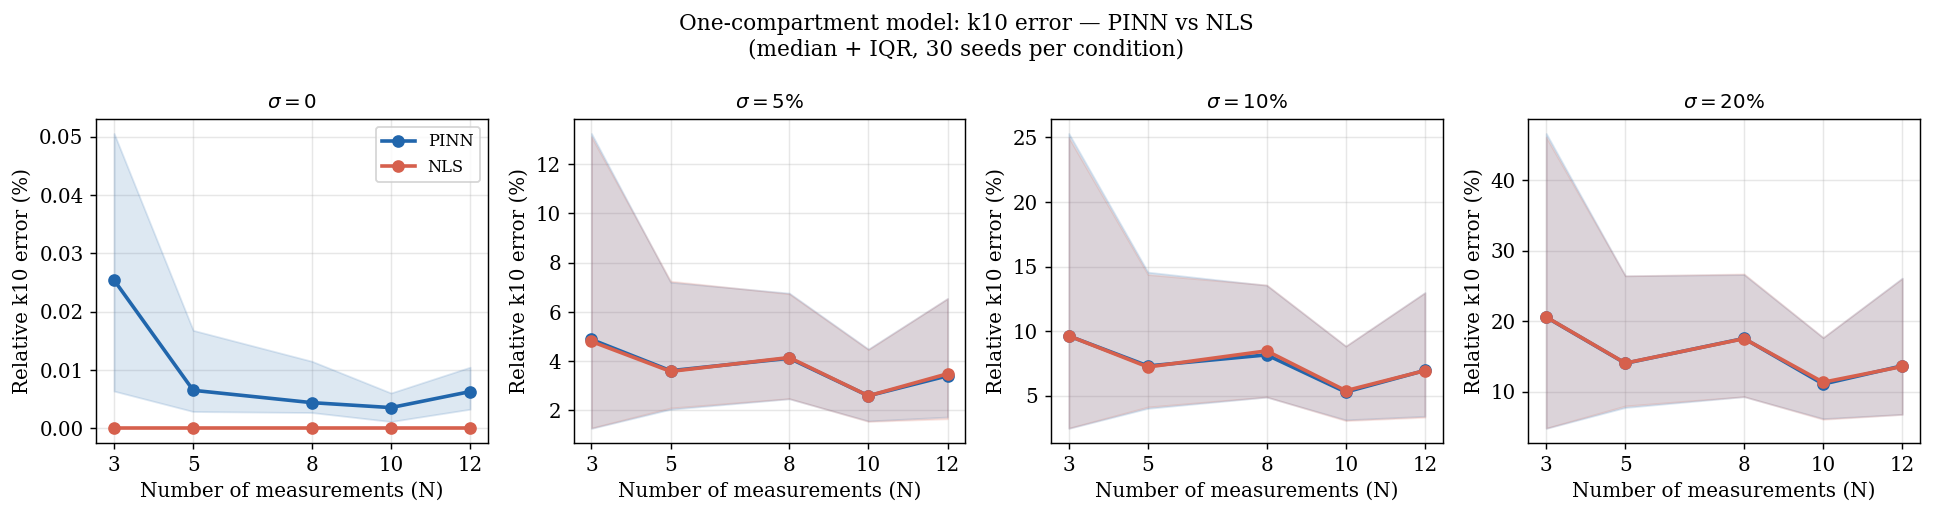

In [22]:
# Fig 1 — k10 error vs N, by noise level
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=False)

for ax, s, sl in zip(axes, SIGMA_VALUES, SIGMA_LABELS):
    line_err_vs_N(df1, "pinn_err_k10", "bench_err_k10",
                  ax, sigma=s,
                  ylabel="Relative k10 error (%)",
                  title=sl)

for ax in axes[1:]:
    ax.get_legend().remove()

plt.suptitle(
    "One-compartment model: k10 error — PINN vs NLS\n"
    "(median + IQR, 30 seeds per condition)",
    fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "04a_1comp_k10_vs_N.png", dpi=150, bbox_inches="tight")
plt.show()

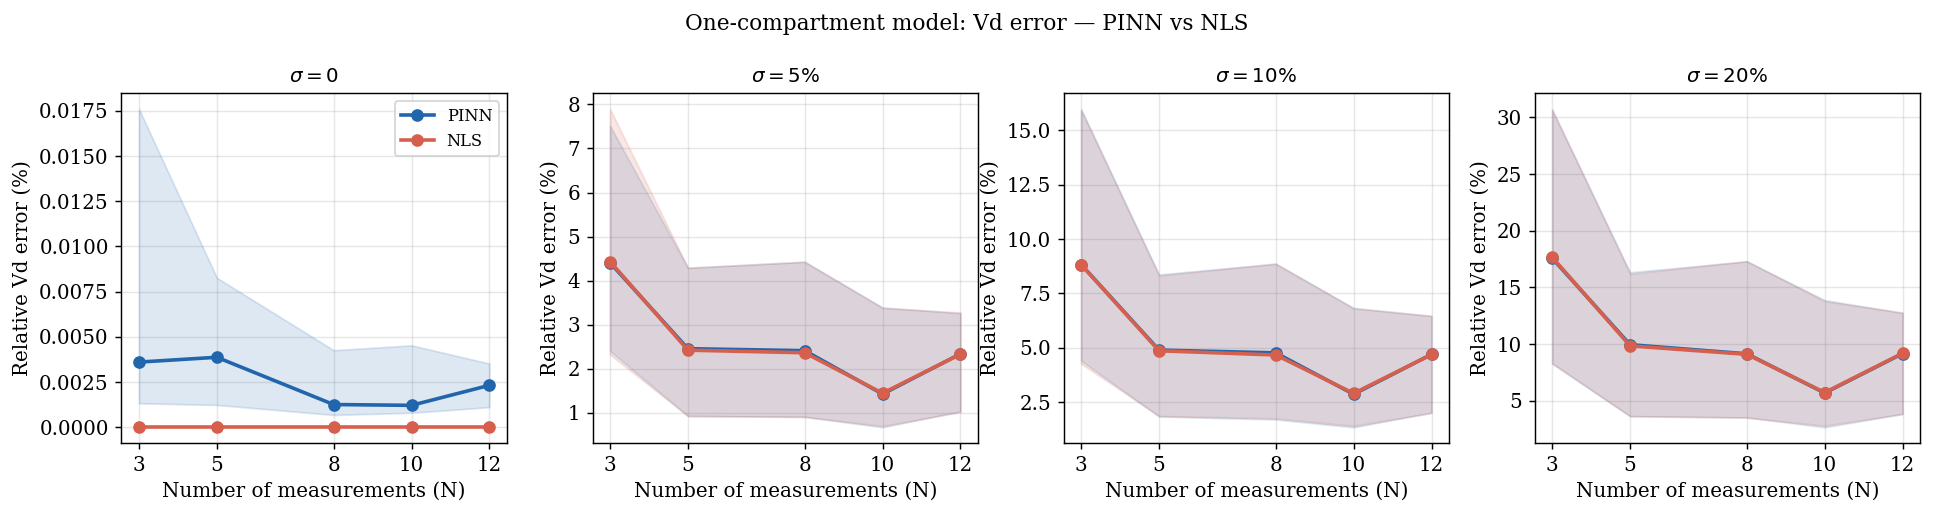

In [23]:
# Fig 2 — Vd error vs N
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=False)

for ax, s, sl in zip(axes, SIGMA_VALUES, SIGMA_LABELS):
    line_err_vs_N(df1, "pinn_err_Vd", "bench_err_Vd",
                  ax, sigma=s,
                  ylabel="Relative Vd error (%)",
                  title=sl)

for ax in axes[1:]:
    ax.get_legend().remove()

plt.suptitle("One-compartment model: Vd error — PINN vs NLS", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "04b_1comp_Vd_vs_N.png", dpi=150, bbox_inches="tight")
plt.show()

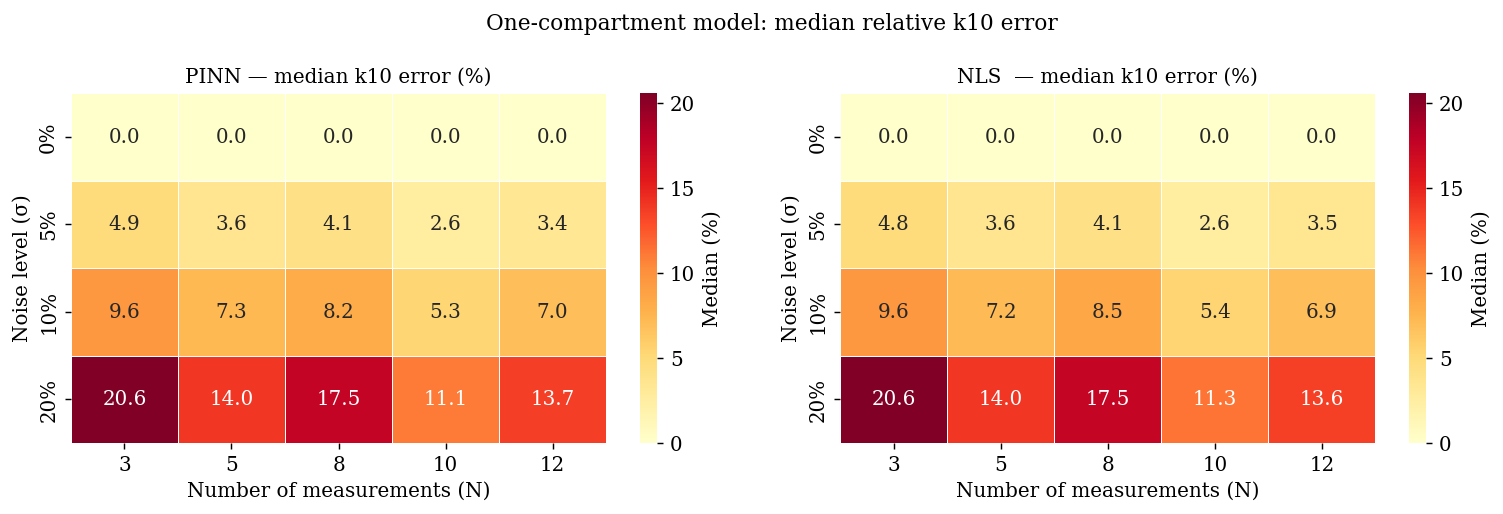

In [24]:
# Fig 3 — heatmaps median k10 error
vmax1 = max(
    df1.groupby(["sigma","N"])["pinn_err_k10"].median().max(),
    df1.groupby(["sigma","N"])["bench_err_k10"].median().max(),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
heatmap_median(df1, "pinn_err_k10",  axes[0], "PINN — median k10 error (%)",  vmax=vmax1)
heatmap_median(df1, "bench_err_k10", axes[1], "NLS  — median k10 error (%)",  vmax=vmax1)

plt.suptitle("One-compartment model: median relative k10 error", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "04c_1comp_heatmap_k10.png", dpi=150, bbox_inches="tight")
plt.show()

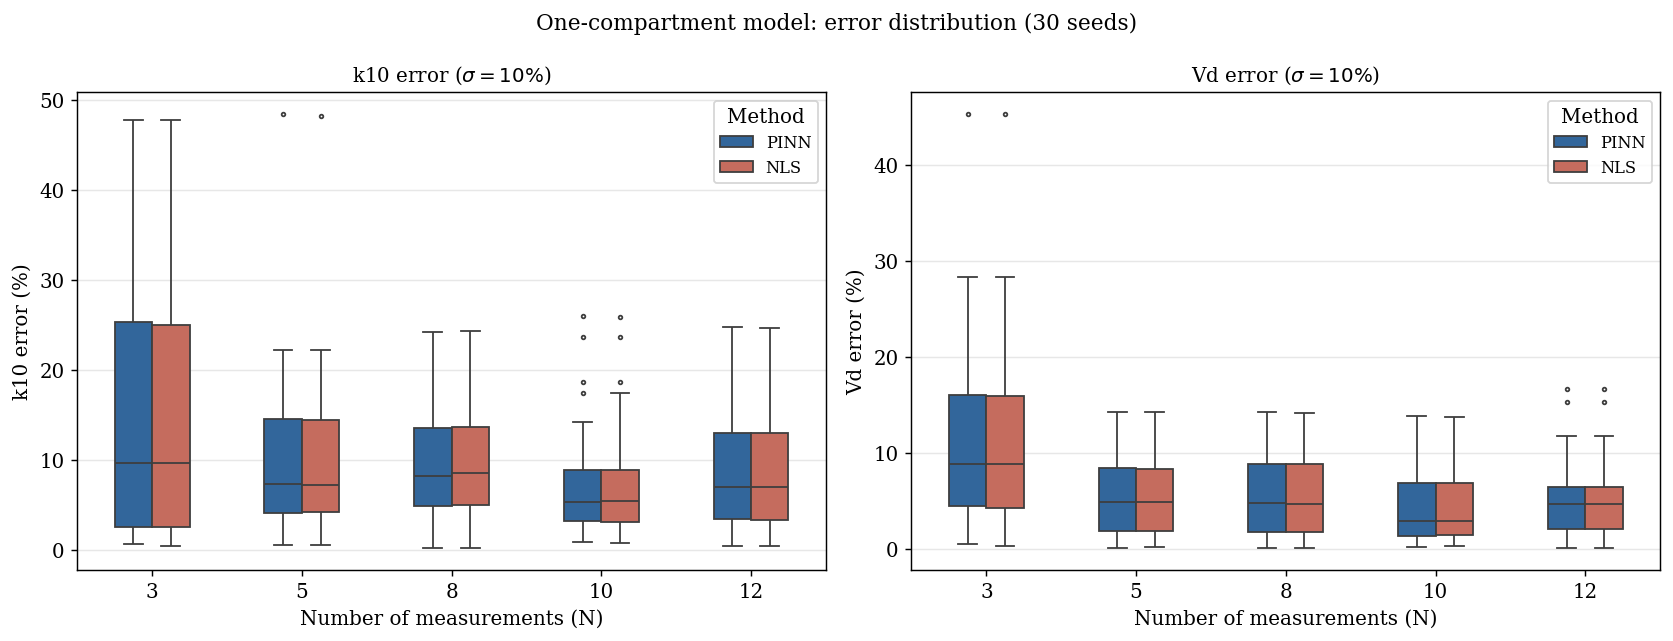

In [25]:
# Fig 4 — box plots for sigma=0.10
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

boxplot_by_N(df1, "pinn_err_k10", "bench_err_k10",
             axes[0], sigma=0.10,
             ylabel="k10 error (%)",
             title=r"k10 error ($\sigma=10\%$)")

boxplot_by_N(df1, "pinn_err_Vd", "bench_err_Vd",
             axes[1], sigma=0.10,
             ylabel="Vd error (%)",
             title=r"Vd error ($\sigma=10\%$)")

plt.suptitle("One-compartment model: error distribution (30 seeds)", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "04d_1comp_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Two-Compartment Model

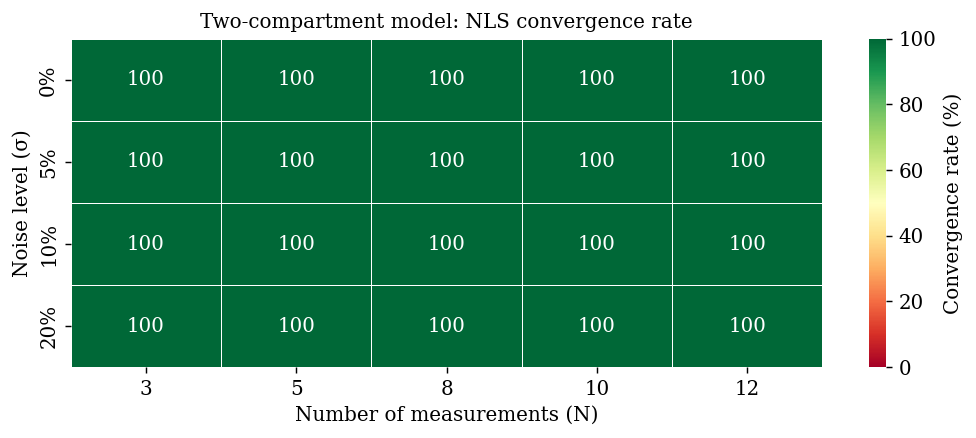

       0%     5%    10%    20%
N                             
3   100.0  100.0  100.0  100.0
5   100.0  100.0  100.0  100.0
8   100.0  100.0  100.0  100.0
10  100.0  100.0  100.0  100.0
12  100.0  100.0  100.0  100.0


In [26]:
# Fig 5 — NLS convergence rate (key for the 2-comp argument)
sr = raw2.groupby(["N","sigma"])["bench_success"].mean().mul(100).unstack("sigma")
sr.columns = [f"{s:.0%}" for s in sr.columns]

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(sr.T, ax=ax, annot=True, fmt=".0f",
            cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Convergence rate (%)"})
ax.set_xlabel("Number of measurements (N)")
ax.set_ylabel("Noise level (σ)")
ax.set_title("Two-compartment model: NLS convergence rate")
plt.tight_layout()
plt.savefig(FIG_DIR / "04e_2comp_nls_success.png", dpi=150, bbox_inches="tight")
plt.show()

print(sr)

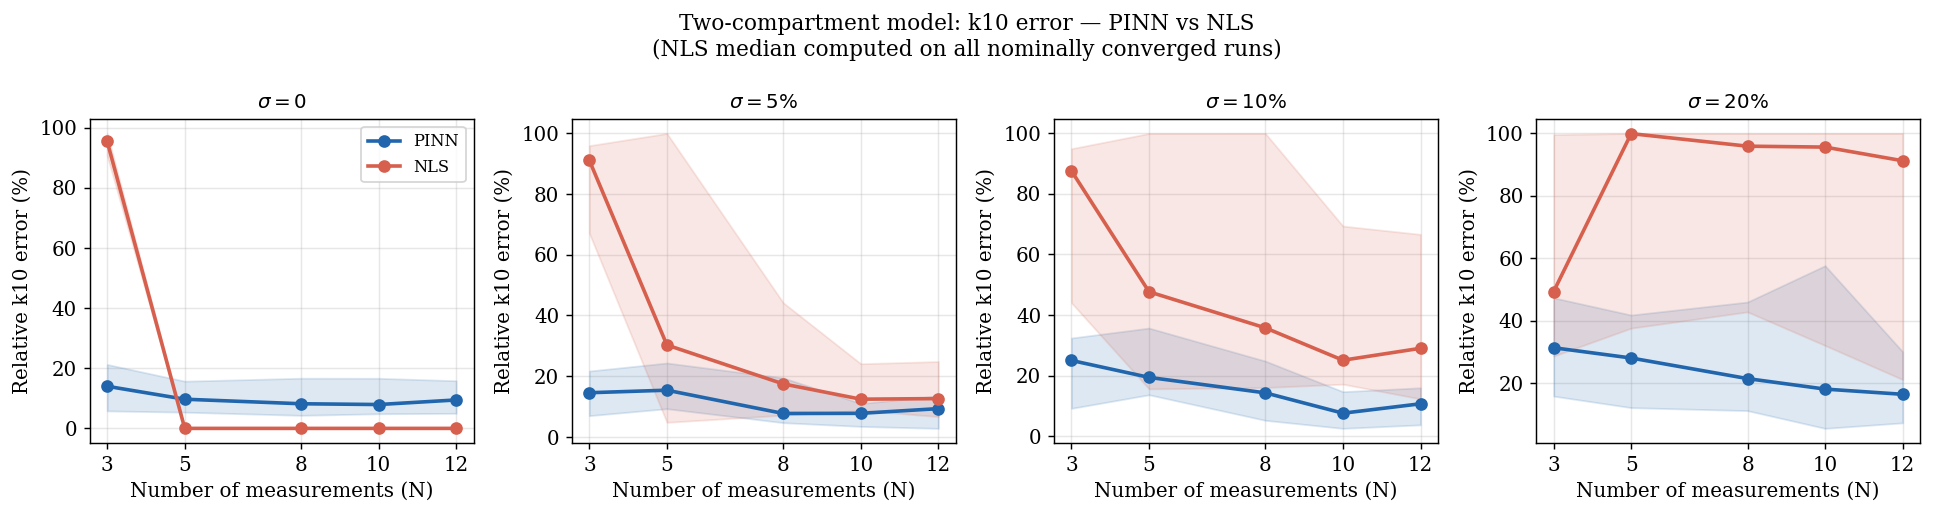

In [27]:
# Fig 6 — k10 error for 2-comp, by noise level
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=False)

for ax, s, sl in zip(axes, SIGMA_VALUES, SIGMA_LABELS):
    line_err_vs_N(df2, "pinn_err_k10", "bench_err_k10",
                  ax, sigma=s,
                  ylabel="Relative k10 error (%)",
                  title=sl)

for ax in axes[1:]:
    ax.get_legend().remove()

plt.suptitle(
    "Two-compartment model: k10 error — PINN vs NLS\n"
    "(NLS median computed on all nominally converged runs)",
    fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "04f_2comp_k10_vs_N.png", dpi=150, bbox_inches="tight")
plt.show()

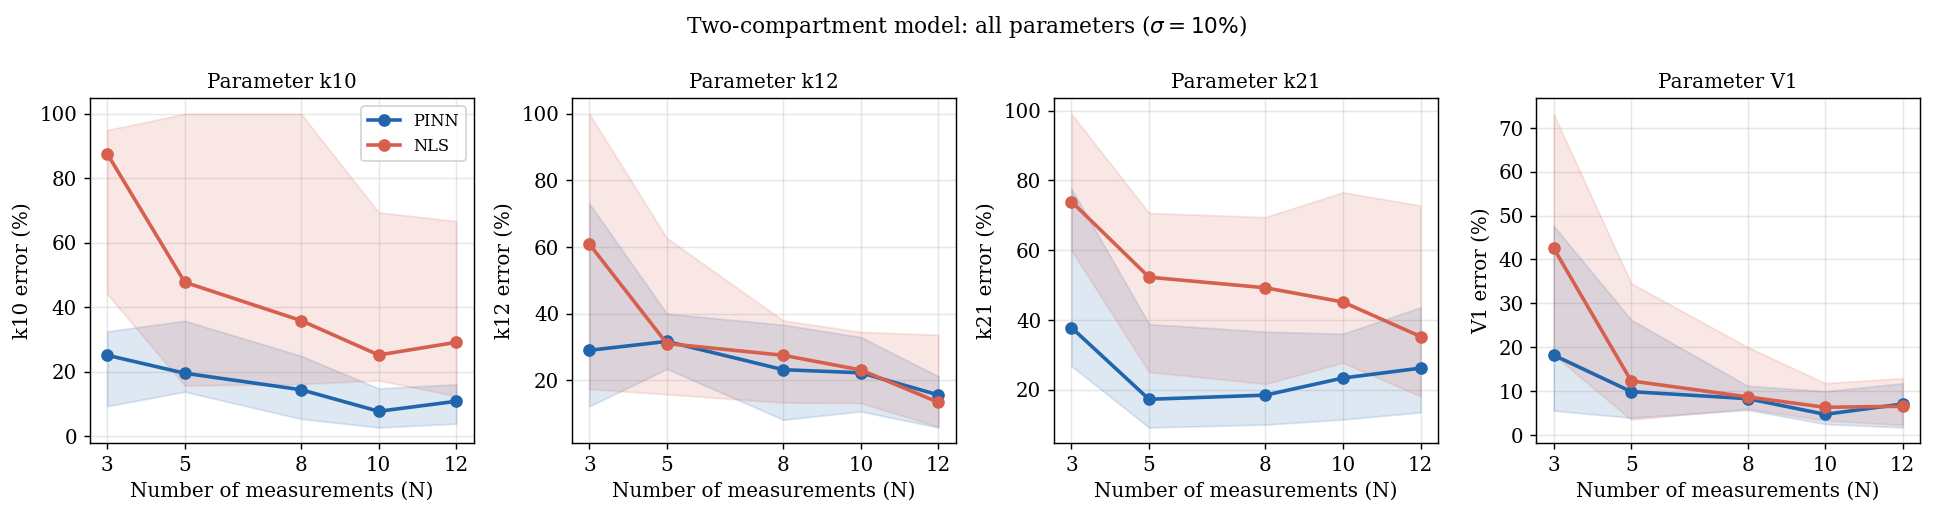

In [28]:
# Fig 7 — all 4 parameters of 2-comp, sigma=0.10
params2 = [
    ("pinn_err_k10", "bench_err_k10", "k10"),
    ("pinn_err_k12", "bench_err_k12", "k12"),
    ("pinn_err_k21", "bench_err_k21", "k21"),
    ("pinn_err_V1",  "bench_err_V1",  "V1"),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=False)
for ax, (pc, bc, lbl) in zip(axes, params2):
    line_err_vs_N(df2, pc, bc, ax, sigma=0.10,
                  ylabel=f"{lbl} error (%)",
                  title=f"Parameter {lbl}")

for ax in axes[1:]:
    ax.get_legend().remove()

plt.suptitle(r"Two-compartment model: all parameters ($\sigma=10\%$)", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "04g_2comp_all_params.png", dpi=150, bbox_inches="tight")
plt.show()

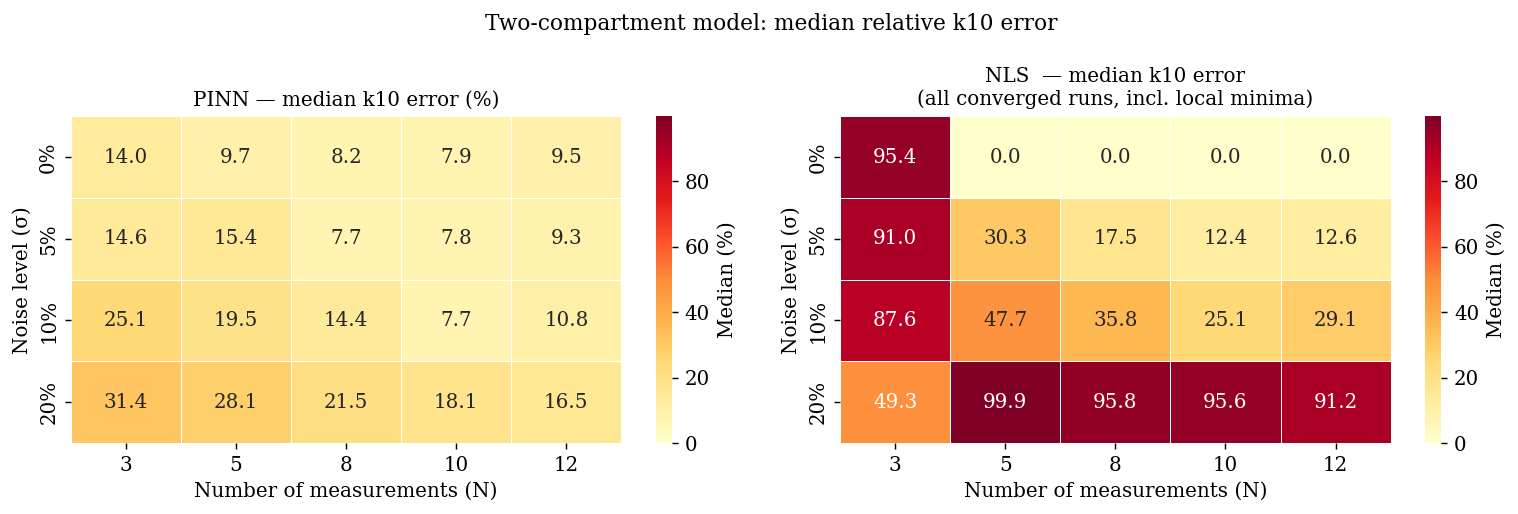

In [29]:
# Fig 8 — heatmaps 2-comp (k10)
# NLS: all 600 runs nominally converged, but many to local minima
df2_nls_ok = df2[df2["bench_success"] == True].copy()

vmax2_pinn  = df2.groupby(["sigma","N"])["pinn_err_k10"].median().max()
vmax2_bench = df2_nls_ok.groupby(["sigma","N"])["bench_err_k10"].median().max() \
              if len(df2_nls_ok) > 0 else vmax2_pinn
vmax2 = max(vmax2_pinn, vmax2_bench)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
heatmap_median(df2,        "pinn_err_k10",  axes[0],
               "PINN — median k10 error (%)",  vmax=vmax2)
heatmap_median(df2_nls_ok, "bench_err_k10", axes[1],
               "NLS  — median k10 error\n(all converged runs, incl. local minima)", vmax=vmax2)

plt.suptitle("Two-compartment model: median relative k10 error", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "04h_2comp_heatmap_k10.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Direct Comparison: PINN vs NLS (Scatter)

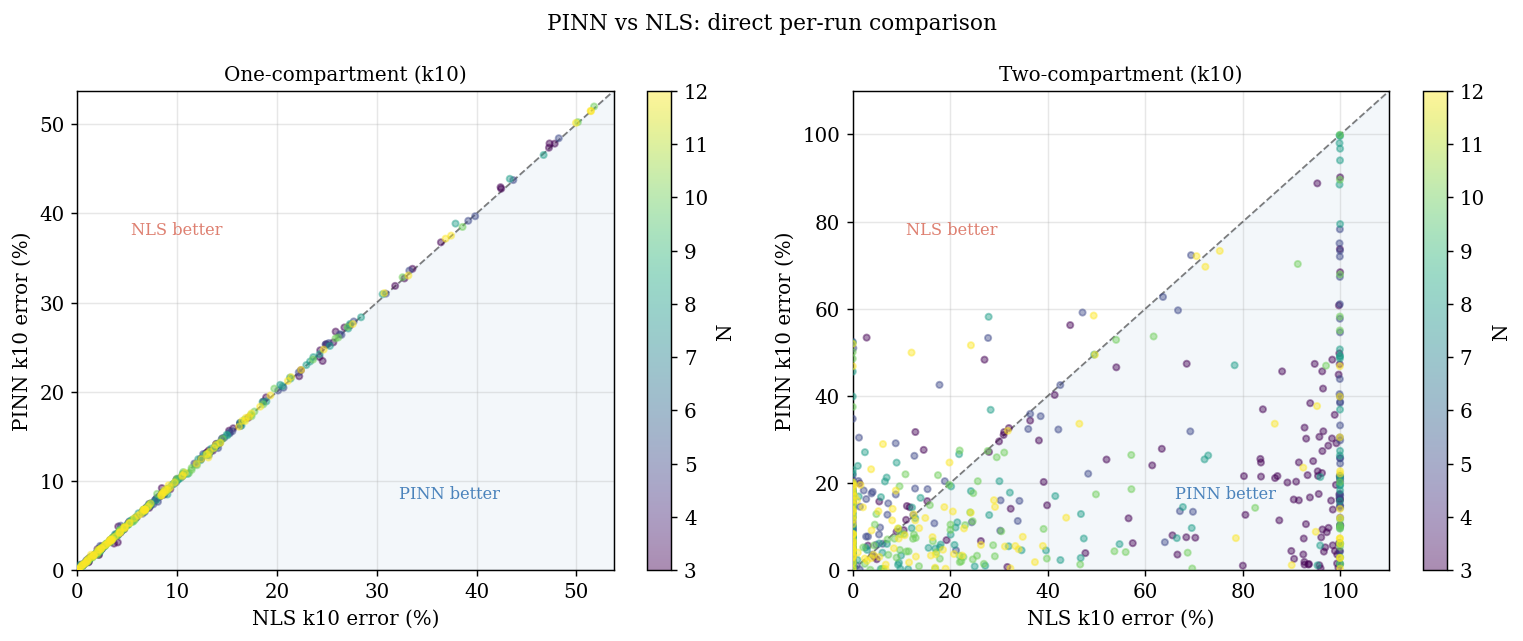

1-comp k10: PINN better in 184/600 runs (30.7%)
2-comp k10: PINN better in 387/600 runs (64.5%)


In [30]:
# Fig 9 — scatter: PINN error vs NLS error, each run is a point
# points below the diagonal = PINN wins
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, lbl, pc, bc in [
    (axes[0], df1, "One-compartment (k10)", "pinn_err_k10", "bench_err_k10"),
    (axes[1], df2, "Two-compartment (k10)", "pinn_err_k10", "bench_err_k10"),
]:
    valid = df[[pc, bc, "N"]].dropna()
    sc = ax.scatter(valid[bc], valid[pc],
                    c=valid["N"], cmap="viridis",
                    alpha=0.45, s=12, vmin=3, vmax=12, zorder=3)
    lim = min(valid[[pc, bc]].quantile(0.97).max() * 1.15, 110)
    ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5)
    ax.fill_between([0, lim], [0, 0], [0, lim],
                    alpha=0.05, color=PINN_C)
    ax.text(lim*0.6, lim*0.15, "PINN better",
            color=PINN_C, fontsize=9, alpha=0.8)
    ax.text(lim*0.1, lim*0.7, "NLS better",
            color=BENCH_C, fontsize=9, alpha=0.8)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("NLS k10 error (%)")
    ax.set_ylabel("PINN k10 error (%)")
    ax.set_title(lbl)
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label="N")

plt.suptitle("PINN vs NLS: direct per-run comparison", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "04i_scatter_pinn_vs_nls.png", dpi=150, bbox_inches="tight")
plt.show()

for df, lbl, pc, bc in [
    (df1, "1-comp k10", "pinn_err_k10", "bench_err_k10"),
    (df2, "2-comp k10", "pinn_err_k10", "bench_err_k10"),
]:
    v = df[[pc, bc]].dropna()
    w = (v[pc] < v[bc]).sum()
    print(f"{lbl}: PINN better in {w}/{len(v)} runs ({w/len(v)*100:.1f}%)")

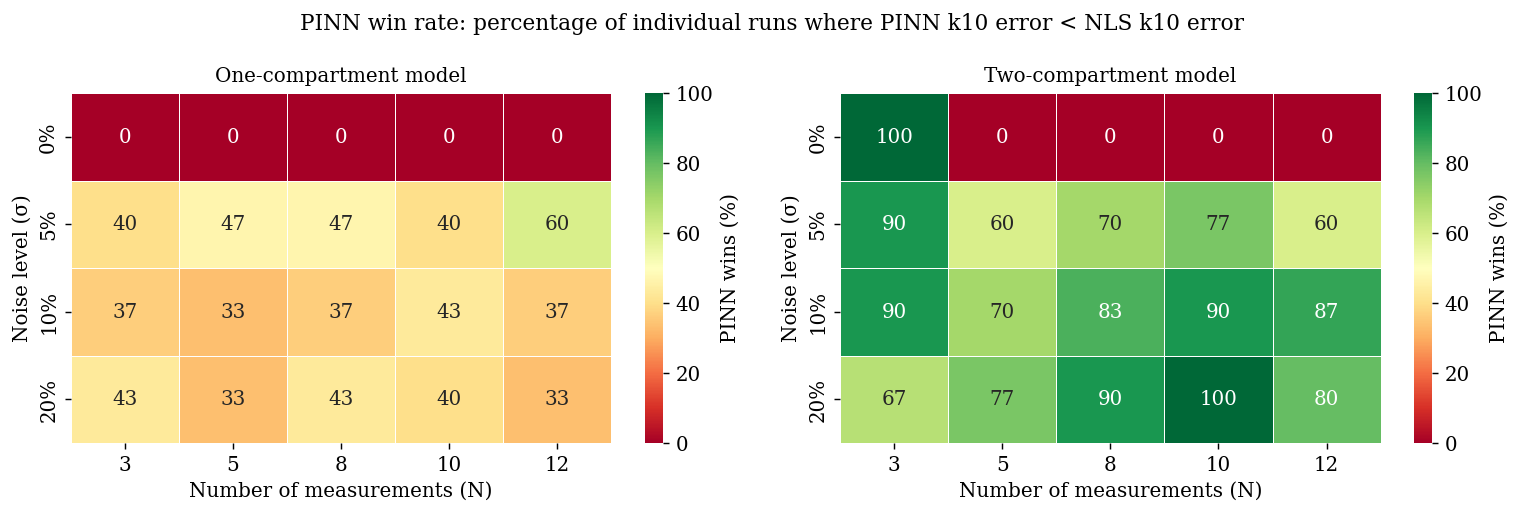

In [31]:
# Fig 10 — Win-rate heatmap: % of individual runs where PINN err_k10 < NLS err_k10
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, lbl in [
    (axes[0], df1, "One-compartment model"),
    (axes[1], df2, "Two-compartment model"),
]:
    valid = df[["N", "sigma", "pinn_err_k10", "bench_err_k10"]].dropna()
    win_rate = (valid.groupby(["sigma", "N"])
                     .apply(lambda g: (g["pinn_err_k10"] < g["bench_err_k10"]).mean() * 100)
                     .unstack("N"))
    win_rate.index = [f"{s:.0%}" for s in win_rate.index]

    sns.heatmap(win_rate, ax=ax, annot=True, fmt=".0f",
                cmap="RdYlGn", vmin=0, vmax=100,
                linewidths=0.5, linecolor="white",
                cbar_kws={"label": "PINN wins (%)"})
    ax.set_xlabel("Number of measurements (N)")
    ax.set_ylabel("Noise level (σ)")
    ax.set_title(lbl)

plt.suptitle(
    "PINN win rate: percentage of individual runs where PINN k10 error < NLS k10 error",
    fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "04j_win_rate_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Summary Table

In [32]:
def build_summary(df, pinn_col, bench_col, bench_ok_df=None):
    """Return DataFrame: median [Q1–Q3] errors for PINN and NLS per (N, sigma)."""
    if bench_ok_df is None:
        bench_ok_df = df
    rows = []
    for s in SIGMA_VALUES:
        for N in N_VALUES:
            pinn_v  = df[(df["sigma"]==s) & (df["N"]==N)][pinn_col].dropna()
            bench_v = bench_ok_df[(bench_ok_df["sigma"]==s) & (bench_ok_df["N"]==N)][bench_col].dropna()

            def fmt(v):
                if len(v) == 0: return "n/a"
                return f"{v.median():.1f} [{v.quantile(.25):.1f}–{v.quantile(.75):.1f}]"

            rows.append({
                "sigma": f"{s:.0%}",
                "N":     N,
                "PINN":  fmt(pinn_v),
                "NLS":   fmt(bench_v),
                "n_pinn":  len(pinn_v),
                "n_nls":   len(bench_v),
            })
    return pd.DataFrame(rows)

tbl1 = build_summary(df1, "pinn_err_k10", "bench_err_k10")
tbl2 = build_summary(df2, "pinn_err_k10", "bench_err_k10",
                     bench_ok_df=df2[df2["bench_success"]==True])

print("=== One-compartment model: err_k10 — median [IQR] (%) ===")
display(tbl1.set_index(["sigma","N"])[["PINN","NLS"]])

print("\n=== Two-compartment model: err_k10 — median [IQR] (%) ===")
print("    (NLS: all nominally converged runs; values near 100% indicate local minima)")
display(tbl2.set_index(["sigma","N"])[["PINN","NLS","n_nls"]])

=== One-compartment model: err_k10 — median [IQR] (%) ===


PINN              NLS
sigma N                                   
0%    3     0.0 [0.0–0.1]    0.0 [0.0–0.0]
      5     0.0 [0.0–0.0]    0.0 [0.0–0.0]
      8     0.0 [0.0–0.0]    0.0 [0.0–0.0]
      10    0.0 [0.0–0.0]    0.0 [0.0–0.0]
      12    0.0 [0.0–0.0]    0.0 [0.0–0.0]
5%    3    4.9 [1.3–13.3]   4.8 [1.3–13.1]
      5     3.6 [2.0–7.2]    3.6 [2.1–7.2]
      8     4.1 [2.5–6.8]    4.1 [2.5–6.7]
      10    2.6 [1.6–4.5]    2.6 [1.5–4.5]
      12    3.4 [1.7–6.5]    3.5 [1.7–6.5]
10%   3    9.6 [2.5–25.3]   9.6 [2.5–25.0]
      5    7.3 [4.0–14.6]   7.2 [4.1–14.4]
      8    8.2 [4.9–13.6]   8.5 [4.9–13.6]
      10    5.3 [3.1–8.8]    5.4 [3.1–8.8]
      12   7.0 [3.4–13.0]   6.9 [3.3–13.0]
20%   3   20.6 [4.8–46.6]  20.6 [4.8–46.1]
      5   14.0 [7.7–26.4]  14.0 [8.0–26.4]
      8   17.5 [9.3–26.6]  17.5 [9.3–26.7]
      10  11.1 [6.2–17.7]  11.3 [6.1–17.7]
      12  13.7 [6.8–26.1]  13.6 [6.8–26.1]


=== Two-compartment model: err_k10 — median [IQR] (%) ===
    (NLS: all nominally converged runs; values near 100% indicate local minima)


PINN               NLS  n_nls
sigma N                                            
0%    3    14.0 [5.8–21.3]  95.4 [90.6–98.0]     30
      5     9.7 [5.4–15.7]     0.0 [0.0–0.0]     30
      8     8.2 [4.3–16.7]     0.0 [0.0–0.0]     30
      10    7.9 [4.9–16.7]     0.0 [0.0–0.0]     30
      12    9.5 [5.0–15.8]     0.0 [0.0–0.0]     30
5%    3    14.6 [7.0–21.7]  91.0 [67.0–95.9]     30
      5    15.4 [9.3–24.4]   30.3 [4.8–99.9]     30
      8     7.7 [4.7–19.5]   17.5 [7.2–44.2]     30
      10    7.8 [3.5–11.0]   12.4 [8.8–24.1]     30
      12    9.3 [2.8–13.5]   12.6 [6.7–24.8]     30
10%   3    25.1 [9.3–32.5]  87.6 [44.1–94.9]     30
      5   19.5 [13.7–35.7]  47.7 [15.7–99.9]     30
      8    14.4 [5.3–24.8]  35.8 [16.1–99.9]     30
      10    7.7 [2.7–14.8]  25.1 [17.2–69.4]     30
      12   10.8 [3.8–16.0]  29.1 [12.4–66.6]     30
20%   3   31.4 [15.9–47.3]  49.3 [28.7–99.5]     30
      5   28.1 [12.2–41.8]  99.9 [37.6–99.9]     30
      8   21.5 [11.2–46.0]  95.8 [42.8–99.9]     30
      10   18.1 [5.5–57.6]  95.6 [32.1–99.9]     30
      12   16.5 [7.3–30.1]  91.2 [21.2–99.9]     30

In [33]:
# Save CSV and LaTeX
tbl1.to_csv(TAB_DIR / "summary_1comp.csv", index=False)
tbl2.to_csv(TAB_DIR / "summary_2comp.csv", index=False)

tex_lines = [
    "% ===== One-compartment model =====",
    "% err_k10 median [Q1-Q3] (%)",
]
tex_lines.append(
    tbl1.set_index(["sigma","N"])[["PINN","NLS"]].to_latex(
        caption="One-compartment model: relative k10 error, median [IQR] (\\%).",
        label="tab:1comp", escape=False)
)
tex_lines += [
    "",
    "% ===== Two-compartment model =====",
    "% NLS: all nominally converged runs",
]
tex_lines.append(
    tbl2.set_index(["sigma","N"])[["PINN","NLS"]].to_latex(
        caption="Two-compartment model: relative k10 error, median [IQR] (\\%). "
                "NLS values include all nominally converged runs.",
        label="tab:2comp", escape=False)
)

tex_path = TAB_DIR / "summary_latex.tex"
tex_path.write_text("\n".join(tex_lines), encoding="utf-8")

print(f"CSV:   {TAB_DIR / 'summary_1comp.csv'}")
print(f"CSV:   {TAB_DIR / 'summary_2comp.csv'}")
print(f"LaTeX: {tex_path}")

CSV:   ..\results\tables\summary_1comp.csv
CSV:   ..\results\tables\summary_2comp.csv
LaTeX: ..\results\tables\summary_latex.tex


---
## 7. PINN vs NLS Win Analysis (by N × σ condition)

In [34]:
print("=" * 60)
print("CONDITIONS WHERE PINN HAS LOWER MEDIAN err_k10 THAN NLS")
print("=" * 60)

for df, lbl, bench_df in [
    (df1, "One-compartment", df1),
    (df2, "Two-compartment", df2[df2["bench_success"]==True]),
]:
    print(f"\n--- {lbl} ---")
    grp_pinn  = df.groupby(["N","sigma"])["pinn_err_k10"].median()
    grp_bench = bench_df.groupby(["N","sigma"])["bench_err_k10"].median()
    comp = pd.DataFrame({"PINN": grp_pinn, "NLS": grp_bench}).dropna()
    wins = comp[comp["PINN"] < comp["NLS"]]
    if wins.empty:
        print("  PINN does not outperform NLS in any condition")
    else:
        for (N, s), row in wins.iterrows():
            print(f"  N={N:2d}, σ={s:.0%}  "
                  f"PINN={row['PINN']:.2f}%  NLS={row['NLS']:.2f}%  "
                  f"(Δ = {row['NLS']-row['PINN']:.2f} pp)")

print()
print("NOTE (2-comp): NLS convergence rate is shown separately in Fig 5.")

CONDITIONS WHERE PINN HAS LOWER MEDIAN err_k10 THAN NLS

--- One-compartment ---
  N= 3, σ=10%  PINN=9.63%  NLS=9.64%  (Δ = 0.01 pp)
  N= 3, σ=20%  PINN=20.56%  NLS=20.58%  (Δ = 0.02 pp)
  N= 5, σ=20%  PINN=14.02%  NLS=14.04%  (Δ = 0.02 pp)
  N= 8, σ=5%  PINN=4.11%  NLS=4.14%  (Δ = 0.03 pp)
  N= 8, σ=10%  PINN=8.16%  NLS=8.47%  (Δ = 0.31 pp)
  N=10, σ=10%  PINN=5.28%  NLS=5.39%  (Δ = 0.11 pp)
  N=10, σ=20%  PINN=11.07%  NLS=11.33%  (Δ = 0.26 pp)
  N=12, σ=5%  PINN=3.40%  NLS=3.48%  (Δ = 0.08 pp)

--- Two-compartment ---
  N= 3, σ=0%  PINN=14.00%  NLS=95.36%  (Δ = 81.36 pp)
  N= 3, σ=5%  PINN=14.57%  NLS=91.04%  (Δ = 76.47 pp)
  N= 3, σ=10%  PINN=25.05%  NLS=87.55%  (Δ = 62.50 pp)
  N= 3, σ=20%  PINN=31.36%  NLS=49.31%  (Δ = 17.95 pp)
  N= 5, σ=5%  PINN=15.41%  NLS=30.27%  (Δ = 14.87 pp)
  N= 5, σ=10%  PINN=19.47%  NLS=47.69%  (Δ = 28.22 pp)
  N= 5, σ=20%  PINN=28.07%  NLS=99.87%  (Δ = 71.80 pp)
  N= 8, σ=5%  PINN=7.75%  NLS=17.47%  (Δ = 9.72 pp)
  N= 8, σ=10%  PINN=14.36%  NLS=35.79%  

In [35]:
# Summary of generated figures
figs = sorted(FIG_DIR.glob("04*.png"))
print(f"Generated {len(figs)} figures:")
for f in figs:
    size_kb = f.stat().st_size // 1024
    print(f"  {f.name}  ({size_kb} KB)")

Generated 10 figures:
  04a_1comp_k10_vs_N.png  (134 KB)
  04b_1comp_Vd_vs_N.png  (134 KB)
  04c_1comp_heatmap_k10.png  (71 KB)
  04d_1comp_boxplots.png  (54 KB)
  04e_2comp_nls_success.png  (43 KB)
  04f_2comp_k10_vs_N.png  (139 KB)
  04g_2comp_all_params.png  (157 KB)
  04h_2comp_heatmap_k10.png  (90 KB)
  04i_scatter_pinn_vs_nls.png  (182 KB)
  04j_win_rate_heatmap.png  (74 KB)
